# Générer des scénarios de fuite étiquetés

Le carnet principal (`00_le_modele_calibre.ipynb`) livre un modèle hydraulique de L-Town qui
reproduit les 33 capteurs de pression à **8,7 cm près sur l'année**. Ce carnet-ci s'en sert à
l'envers.

Un détecteur de fuite s'entraîne et s'évalue sur des exemples dont on connaît la réponse. Or dans
la vraie vie on ne la connaît jamais : on sait qu'une conduite a été réparée tel jour, rarement
quand elle s'est percée, presque jamais de combien elle coulait. Le jeu de données de L-Town publie
quatorze fuites pour 2018 — c'est peu pour entraîner quoi que ce soit, et c'est la seule année
étiquetée.

Avec un modèle calibré, on peut en fabriquer autant qu'on veut :

* on **choisit** la conduite, l'instant d'ouverture, l'instant de réparation et le débit ;
* on simule ce que les 33 capteurs auraient vu ;
* l'étiquette est exacte **par construction**, puisque c'est nous qui avons posé la fuite.

Ce carnet explique comment, montre ce que cela vaut, et produit un lot qu'on peut relire sans lui.

## Le plan

1. ce que le modèle sait faire, et ce que cela impose aux scénarios qu'on peut fabriquer ;
2. le modèle dont on part, en une cellule ;
3. une fuite est un **émetteur** : `Q = C·√p`, et pourquoi on ne fixe pas un débit ;
4. on ne simule que ce qui change — et pourquoi le recollement est exact ;
5. un scénario en détail, courbes à l'appui ;
6. la même fuite ne se voit pas partout : le balayage qui trie le facile du difficile ;
7. le lot : une trentaine de scénarios écrits sur disque ;
8. relire le lot sans ce carnet.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, ameliorations as A
from calibration import generation as Gen, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
R.verifier_donnees(ANNEE)

# Une quinzaine de janvier : la période la plus saine de l'année selon le fichier de fuites.
# On fabrique les nôtres par-dessus un réseau quasiment sain, et non par-dessus des fuites qu'on
# ignorerait — la cellule suivante chiffre ce « quasiment ».
DEBUT, N_PAS = 0, 14 * R.PAS_JOUR
print(f"fenêtre : {N_PAS} pas de {R.PAS_MIN} min, soit {N_PAS / R.PAS_JOUR:.0f} jours")
print(f"grain des dates de fuite : {Gen.PAS_TRANCHE} pas, soit "
      f"{Gen.PAS_TRANCHE * R.PAS_MIN / 60:.0f} h")

fenêtre : 4032 pas de 5 min, soit 14 jours
grain des dates de fuite : 72 pas, soit 6 h


## 1. Ce que le modèle sait faire, et ce que cela impose

Avant de fabriquer quoi que ce soit, il faut savoir ce qu'on a le droit de fabriquer. Un scénario
dont la signature est plus petite que l'erreur du modèle est un scénario que **personne** ne peut
résoudre à partir des pressions : il n'apprendrait à un détecteur qu'à deviner.

On commence donc par mesurer l'erreur du modèle sur la fenêtre choisie. C'est le plancher, et il
servira de repère dans tout le reste du carnet.

In [2]:
wn = R.charger_modele()
noeuds = wn.junction_name_list
capteurs = R.capteurs()["pressure"]
colonnes = [noeuds.index(c) for c in capteurs]

niveau = R.charger_niveau(ANNEE).to_numpy()
statut = A.statut_pompe(ANNEE)
p_mes = R.charger_pressions(ANNEE).to_numpy()
horo = R.horodatage(ANNEE)

# Ce que le fichier de fuites publie sur la fenêtre : de quoi savoir sur quoi on construit.
charge = R.charge_de_fuite(ANNEE, DEBUT, N_PAS)
print(f"fuites publiées sur la fenêtre : {charge['debit_m3h']:.2f} m³/h en moyenne, "
      f"soit {charge['part_conso_ab']:.2%} de la consommation de la zone A+B")

fuites publiées sur la fenêtre : 0.15 m³/h en moyenne, soit 0.09% de la consommation de la zone A+B


## 2. Le modèle dont on part

Trois lignes, et c'est tout le carnet principal :

* la **demande** vient de l'équation (2) — les formes horaires extraites des 82 compteurs, pondérées
  par les demandes nominales de chaque nœud — puis on **remplace** par la mesure là où un compteur
  existe ;
* les **conditions aux limites** ne sont pas simulées mais lues : l'état réel de la pompe au
  débitmètre, et le niveau du réservoir réancré sur son capteur toutes les 6 h ;
* les **rugosités** sont les treize coefficients ajustés une fois pour toutes sur deux jours de
  janvier, par groupes homogènes de zone × coefficient × diamètre.

On ne recale **pas** la demande de la zone A+B sur le bilan des débitmètres : ce bilan contient les
fuites, et les verser dans la demande reviendrait à effacer d'avance ce qu'on cherche à fabriquer.

In [3]:
# Les treize coefficients livrés par le carnet principal.
COEFFICIENTS = {"AB|C120|D100": 108.0, "AB|C120|D150": 108.0, "AB|C120|D63": 131.5,
                "AB|C140|D100": 129.5, "AB|C140|D150": 141.3, "AB|C140|D160": 151.3,
                "AB|C140|D200": 127.4, "AB|C140|D225": 147.7, "AB|C140|D63": 126.7,
                "AB|C140|D75": 126.0, "C|C140|D100": 126.7, "C|C140|D200": 154.0,
                "frontiere|C140|D200": 154.0}
groupes = R.groupes_de_rugosite(wn, critere="physique")
coefs = {p: COEFFICIENTS[g] for p, g in groupes.items()}

D, _ = P.demandes_calibrees(wn, ANNEE, n_pas=DEBUT + N_PAS + 1)     # équations (1) et (2)
D = A.injecter_compteurs(D, noeuds, ANNEE)[DEBUT:DEBUT + N_PAS + 1]  # la mesure là où elle existe

BORNES = dict(pompe=statut[DEBUT:DEBUT + N_PAS + 1],
              niveau_mesure=niveau[DEBUT:DEBUT + N_PAS + 1],
              niveau0=float(niveau[DEBUT]), coefficients=coefs, verbeux=False)
print(f"demandes : {D.shape}, {D.nbytes / 1e6:.0f} Mo — moyenne {D[:, :].sum(axis=1).mean():.1f} m³/h")

demandes : (4033, 782), 13 Mo — moyenne 153.6 m³/h


In [4]:
# Le témoin : la fenêtre simulée sans aucune fuite. Il servira trois fois — de référence pour
# dimensionner les émetteurs, de portion avant-fuite, et d'exemple négatif pour un détecteur.
propre = Gen.fenetre_propre(D, noeuds, N_PAS, **BORNES)

erreur = G.resume(propre[:, colonnes], p_mes[DEBUT:DEBUT + N_PAS])
print("erreur du modèle calibré sur la fenêtre, aux 33 capteurs :")
print(pd.Series(erreur).round(4).to_string())

erreur du modèle calibré sur la fenêtre, aux 33 capteurs :
biais_m           -0.0061
dispersion_m       0.0588
rmse_m             0.0591
max_m              0.3588
n_pas           4032.0000


### Lecture — le plancher, et ce qu'il interdit

Deux chiffres à retenir de ce qui précède.

D'abord, la fenêtre n'est pas parfaitement propre : le fichier publie **0,15 m³/h** de fuite en
moyenne, soit 0,09 % de la consommation de la zone. C'est mille fois moins que les scénarios qu'on
va fabriquer, donc négligeable — mais il fallait le chiffrer plutôt que de l'affirmer. Aucune autre
période de l'année n'est aussi calme.

Ensuite le plancher, et c'est le chiffre qui commande tout le reste de ce carnet. Le modèle se
trompe de quelques centimètres, et **une fuite dont la signature est plus petite que cela est indétectable par les
pressions** — quel que soit l'algorithme, et quelle que soit la quantité de données qu'on lui
donne.

Fabriquer de tels scénarios n'est pas inutile pour autant : un jeu qui ne contiendrait que des
fuites énormes donnerait un détecteur qui a l'air excellent et qui ne sert à rien. Mais il faut
**savoir** lesquels sont solubles, et c'est pour cela que le §6 mesure la signature de chaque
scénario avant de l'écrire.

## 3. Une fuite est un émetteur, pas un débit

EPANET ne sait pas percer une conduite. Il sait poser sur un nœud un **émetteur**, c'est-à-dire un
soutirage qui dépend de la pression :

$$ Q = C \cdot p^{\,0{,}5} $$

Cette forme n'est pas un choix de commodité : elle décrit un orifice, et le jeu de données de
L-Town a lui-même produit ses fuites de cette façon.

La conséquence est qu'**on ne fixe pas un débit, on fixe un coefficient**. Pour obtenir un débit
visé $Q_0$, il faut connaître la pression $p_0$ qui régnera au nœud, et poser $C = Q_0/\sqrt{p_0}$.
Comme la fuite fait elle-même baisser la pression, le débit obtenu est un peu inférieur à la
cible ; c'est le débit **réellement délivré** qu'on enregistre comme étiquette, pas la consigne.

Deux détails qui comptent :

* une fuite est sur une **conduite**, l'émetteur est sur un **nœud**. On prend une extrémité de la
  conduite, ce qui déplace la fuite d'une demi-longueur au plus — quelques dizaines de mètres, à
  comparer aux centaines de mètres qui séparent deux capteurs ;
* la pression de référence se lit sur le **témoin**, à ce nœud, moyennée sur la durée de la fuite.

In [5]:
conduite = "p232"
noeud = Gen.noeud_perce(wn, conduite, noeuds)
k = noeuds.index(noeud)
p_ref = float(propre[:, k].mean())
c = R.coefficient_emetteur(10.0, p_ref)

print(f"conduite {conduite} → nœud {noeud}")
print(f"pression au nœud sain : {p_ref:.2f} m")
print(f"coefficient d'émetteur pour viser 10 m³/h : {c:.5f}  (unités SI)")
print(f"vérification : {c * np.sqrt(p_ref) * 3600:.2f} m³/h sous cette pression")

conduite p232 → nœud n184
pression au nœud sain : 46.99 m
coefficient d'émetteur pour viser 10 m³/h : 0.00041  (unités SI)
vérification : 10.00 m³/h sous cette pression


## 4. On ne simule que ce qui change

Une fenêtre de quinze jours coûte une quinzaine de secondes de simulation. Multipliée par trente
scénarios, elle en coûterait huit minutes — et par trois cents, une heure et demie. C'est évitable.

Une fuite qui s'ouvre au pas $t_0$ et qu'on répare au pas $t_1$ ne change **rien** avant $t_0$ ni
après $t_1$. On peut donc recoller trois morceaux : le témoin avant, la simulation avec émetteur
pendant, le témoin après. Chaque scénario ne coûte alors que la durée pendant laquelle la fuite
coule.

Ce recollement n'est licite que parce que le modèle **réancre le niveau du réservoir sur son
capteur toutes les 6 h**. Sans cela, le stock du réservoir intégrerait la fuite et les deux
morceaux ne se rejoindraient pas. C'est aussi pour cela que les dates d'ouverture et de réparation
sont contraintes à tomber sur une frontière de tranche : `generation.PAS_TRANCHE`.

Vérifions-le plutôt que de le croire.

In [6]:
fuite = Gen.Fuite(conduite=conduite, debut=4 * R.PAS_JOUR, fin=9 * R.PAS_JOUR, debit_m3h=10.0)
pressions, debit = Gen.poser(D, noeuds, N_PAS, wn, fuite, propre, **BORNES)

avant = np.abs(pressions[:fuite.debut] - propre[:fuite.debut]).max()
apres = np.abs(pressions[fuite.fin:] - propre[fuite.fin:]).max()
pendant = np.abs(pressions[fuite.debut:fuite.fin] - propre[fuite.debut:fuite.fin]).max()

print(f"écart au témoin avant l'ouverture   : {avant:.3e} m")
print(f"écart au témoin après la réparation : {apres:.3e} m")
print(f"écart au témoin pendant la fuite    : {pendant:.4f} m")
print(f"\npas simulés : {fuite.fin - fuite.debut} sur {N_PAS} "
      f"({(fuite.fin - fuite.debut) / N_PAS:.0%} de la fenêtre)")

écart au témoin avant l'ouverture   : 0.000e+00 m
écart au témoin après la réparation : 0.000e+00 m
écart au témoin pendant la fuite    : 0.2438 m

pas simulés : 1440 sur 4032 (36% de la fenêtre)


### Lecture

Zéro exact avant et après — pas « petit », **nul**, puisque ces pas ne sont pas recalculés mais
recopiés du témoin. Et 36 % de la fenêtre simulée au lieu de 100 %.

Le gain se lit mieux à l'échelle d'un lot. Celui du §7 contient trente-six scénarios sur cette
fenêtre de quatorze jours : il demande **147 jours de simulation au lieu de 504**, soit trois fois
et demie moins. Et le rapport s'améliore encore avec des fuites plus courtes, qui sont aussi les
plus intéressantes à détecter.

## 5. Un scénario, en détail

Voici ce que la fuite fait aux capteurs, et ce qu'elle soutire réellement.

{
  "conduite": "p232",
  "debut": 1152,
  "fin": 2592,
  "debit_m3h": 10.0,
  "profil": "abrupt",
  "paliers": 4,
  "noeud_perce": "n184",
  "longueur_m": 74.298,
  "diametre_mm": 100.0,
  "pas_avec_fuite": 1440,
  "debit_reel_m3h": 9.982819557189941,
  "debit_reel_max_m3h": 10.058479309082031,
  "volume_perdu_m3": 1197.938232421875
}


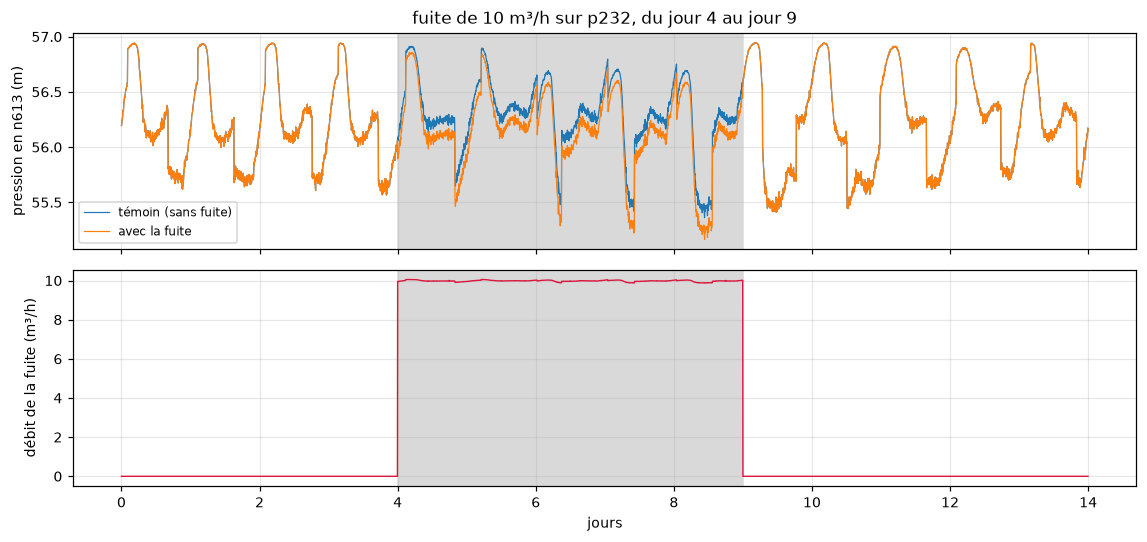

In [7]:
baisse = (propre[:, colonnes] - pressions[:, colonnes])
touche = int(baisse[fuite.debut:fuite.fin].mean(axis=0).argmax())
j = np.arange(N_PAS) / R.PAS_JOUR

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.0), sharex=True)
axes[0].plot(j, propre[:, colonnes][:, touche], lw=0.8, label="témoin (sans fuite)")
axes[0].plot(j, pressions[:, colonnes][:, touche], lw=0.8, label="avec la fuite")
axes[0].set_ylabel(f"pression en {capteurs[touche]} (m)"); axes[0].legend(fontsize=8)
axes[0].set_title(f"fuite de {fuite.debit_m3h:.0f} m³/h sur {conduite}, "
                  f"du jour {fuite.debut // R.PAS_JOUR} au jour {fuite.fin // R.PAS_JOUR}")
axes[1].plot(j, debit, lw=0.9, color="crimson")
axes[1].set_ylabel("débit de la fuite (m³/h)"); axes[1].set_xlabel("jours")
for a in axes:
    a.axvspan(fuite.debut / R.PAS_JOUR, fuite.fin / R.PAS_JOUR, color="0.85", zorder=0)
fig.tight_layout()

verite = Gen.etiquette(wn, noeuds, fuite, debit, N_PAS)
print(json.dumps(verite, indent=2, ensure_ascii=False))

### Lecture — l'étiquette dit ce qui a été simulé, pas ce qu'on a demandé

Le débit visé était 10 m³/h ; l'étiquette porte le débit **réellement soutiré**, qui respire avec
la pression du réseau au fil de la journée. C'est lui la vérité terrain : un détecteur évalué sur
la consigne serait jugé sur une grandeur qui n'a jamais existé dans la simulation.

Le volume perdu est l'étiquette la plus utile pour une évaluation économique : c'est l'eau qu'une
détection plus précoce aurait économisée.

Et sur la courbe du haut, la chose à retenir : **le décrochement est constant, pas la pression**.
La pression continue d'osciller au rythme de la demande, avec la même forme qu'avant ; ce qui
change est un décalage. Un détecteur qui cherche une rupture de niveau dans une série cyclique
cherche la bonne chose.

## 6. La même fuite ne se voit pas partout

Dix mètres cubes par heure, c'est dix mètres cubes par heure où qu'on les perce. Mais ce que les
capteurs en voient dépend entièrement de **l'endroit** : une fuite loin de tout capteur se dilue
dans le réseau avant d'atteindre le premier manomètre.

C'est la propriété la plus importante à connaître avant de fabriquer un lot. Un lot composé de
fuites faciles donne un détecteur qui a l'air très bon et qui ne l'est pas ; un lot composé de cas
insolubles lui apprend surtout à se taire. Dans les deux cas on ne mesure plus rien.

L'hypothèse naturelle est que ce qui compte est la **distance au capteur le plus proche** : une
fuite loin de tout manomètre se dilue avant d'être vue. Mesurons-la plutôt que de la supposer — on
classe les 905 conduites par cette distance, le long des conduites, et on pose la même fuite de
10 m³/h à huit endroits échelonnés.

In [8]:
import networkx as nx

g = R.graphe(wn)
# distance à la source la plus proche parmi les 33 capteurs, le long des conduites
dist = nx.multi_source_dijkstra_path_length(g, set(capteurs), weight="length")
zones_n = R.zones(wn)

tab_conduites = pd.DataFrame([
    {"conduite": p,
     "noeud": Gen.noeud_perce(wn, p, noeuds),
     "zone": zones_n.get(Gen.noeud_perce(wn, p, noeuds)),
     "distance_m": dist.get(Gen.noeud_perce(wn, p, noeuds), np.inf),
     "diametre_mm": wn.get_link(p).diameter * 1000}
    for p in wn.pipe_name_list])

print("distance au capteur le plus proche, sur les 905 conduites :")
print(tab_conduites["distance_m"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(0).to_string())

distance au capteur le plus proche, sur les 905 conduites :
count    905.0
mean     184.0
std      106.0
min        0.0
10%       51.0
25%      102.0
50%      170.0
75%      253.0
90%      329.0
max      501.0


In [9]:
# Huit conduites échelonnées du plus proche au plus lointain, pour couvrir toute la gamme.
echantillon = (tab_conduites.sort_values("distance_m")
               .iloc[np.linspace(0, len(tab_conduites) - 1, 8).astype(int)])

lignes = []
for _, r in echantillon.iterrows():
    f = Gen.Fuite(conduite=r["conduite"], debut=0, fin=R.PAS_JOUR, debit_m3h=10.0)
    pr, db = Gen.poser(D, noeuds, N_PAS, wn, f, propre, **BORNES)
    b = (propre[:R.PAS_JOUR, colonnes] - pr[:R.PAS_JOUR, colonnes]).mean(axis=0)
    lignes.append({"conduite": r["conduite"], "zone": r["zone"],
                   "distance_m": r["distance_m"], "diametre_mm": r["diametre_mm"],
                   "debit_reel": db[db > 0].mean(),
                   "baisse_max_cm": 100 * b.max(),
                   "capteur": capteurs[int(b.argmax())],
                   "baisse_mediane_cm": 100 * np.median(b)})

balayage = pd.DataFrame(lignes)
balayage["signal_sur_erreur"] = balayage["baisse_max_cm"] / (100 * erreur["dispersion_m"])
print(f"une fuite de 10 m³/h posée à huit endroits "
      f"(dispersion du modèle : {100 * erreur['dispersion_m']:.1f} cm)")
print(balayage.round(2).to_string(index=False))

une fuite de 10 m³/h posée à huit endroits (dispersion du modèle : 5.9 cm)
conduite zone  distance_m  diametre_mm  debit_reel  baisse_max_cm capteur  baisse_mediane_cm  signal_sur_erreur
    p823   AB        0.00        100.0        9.98      21.150000    n726               5.07               3.60
    p467   AB       67.81        100.0        9.98      18.570000    n114               6.08               3.16
    p133   AB      111.08        100.0        9.98      16.000000    n549               6.99               2.72
    p304    C      153.93        100.0        9.96      27.160000     n31               0.01               4.62
    p666   AB      193.92        100.0        9.98      15.620000    n613               6.27               2.66
    p404   AB      240.42        100.0        9.98      14.830000     n54               6.29               2.52
     p31    C      305.99        100.0        9.96      25.469999     n31               0.01               4.33
    p167   AB      501.02    

### Lecture — ce n'est pas un gradient, ce sont deux régimes

L'hypothèse de départ se vérifie, mais elle est **secondaire**, et le tableau montre pourquoi.

**À l'intérieur de la zone A+B, la distance joue comme prévu** — et modestement. De 0 m à 501 m,
la baisse maximale passe de 21,2 cm à 14,1 cm, en décroissant à chaque palier. Un facteur 1,5 sur
toute la gamme : réel, régulier, mais ce n'est pas là que se joue la difficulté.

**Les deux conduites de la zone C cassent complètement le classement.** `p304` à 154 m et `p31` à
306 m donnent les deux plus fortes baisses du tableau — 27,2 et 25,5 cm — alors que leur baisse
**médiane sur les 33 capteurs est de 0,01 cm**, contre 5 à 7 cm pour toutes les conduites de A+B.

Autrement dit, ces deux fuites sont **invisibles partout sauf en un point**, où elles sont énormes.
C'est la topologie qui parle : la zone C est alimentée par le seul réservoir, à travers une seule
conduite de transport. Une fuite en A+B tire sur les deux conduites d'entrée du réseau et abaisse
donc un peu *tous* les capteurs ; une fuite en zone C tire sur un réservoir dont le niveau est
réancré sur son capteur toutes les 6 h, si bien que rien ne se propage au-delà de la frontière.

Deux conséquences pour la suite :

* le bon axe de difficulté n'est pas la distance seule, c'est **la zone d'abord, la distance
  ensuite** — et un lot doit couvrir les deux régimes, sous peine de n'enseigner qu'un seul ;
* c'est aussi l'explication d'un résultat du carnet principal, où une fuite de 10 m³/h donnait
  52,7 cm à un endroit et 10,0 cm à un autre. L'endroit qui donnait 52,7 cm était `p257` — une
  conduite de la zone C.

## 7. Le lot

On compose maintenant un lot en croisant trois choses :

* **l'endroit** — neuf conduites de A+B échelonnées sur la distance au capteur, et trois de la
  zone C, pour couvrir les deux régimes que le §6 vient de séparer ;
* **le débit** — de 3 à 30 m³/h, soit de 2 % à 19 % de la consommation de la zone A+B ;
* **le profil** — `abrupt` pour une casse, `progressif` pour une fuite naissante qui monte
  lentement, les deux familles que le jeu de données de L-Town distingue lui-même.

Chaque scénario s'ouvre et se referme à une date différente : un détecteur ne doit pas pouvoir
tricher en apprenant que « la fuite commence toujours au jour 4 ».

In [10]:
rng = np.random.default_rng(0)

def echelonner(sous_table, n):
    t = sous_table.sort_values("distance_m")
    return t.iloc[np.linspace(0, len(t) - 1, n).astype(int)]["conduite"].to_list()

# Les deux régimes du §6, et la distance à l'intérieur de chacun. Tirer au hasard sur les 905
# conduites ne donnerait presque que de la zone A+B : elle en porte 813 sur 905.
choix = (echelonner(tab_conduites[tab_conduites["zone"] == "AB"], 9)
         + echelonner(tab_conduites[tab_conduites["zone"] == "C"], 3))

lot = []
for i, cond in enumerate(choix):
    for debit, profil in [(3.0, "abrupt"), (12.0, "abrupt"), (30.0, "progressif")]:
        d0 = int(rng.integers(2, 8)) * R.PAS_JOUR
        d1 = d0 + int(rng.integers(3, 6)) * R.PAS_JOUR
        lot.append(Gen.Fuite(conduite=cond, debut=d0, fin=min(d1, N_PAS),
                             debit_m3h=debit, profil=profil))

zone_de = dict(zip(tab_conduites["conduite"], tab_conduites["zone"]))
print(f"{len(lot)} scénarios : {len(choix)} conduites × 3 réglages")
print(f"  dont zone AB : {sum(zone_de[c] == 'AB' for c in choix)} conduites, "
      f"zone C : {sum(zone_de[c] == 'C' for c in choix)}")
print(f"durée cumulée à simuler : {sum(f.fin - f.debut for f in lot) / R.PAS_JOUR:.0f} jours "
      f"contre {len(lot) * N_PAS / R.PAS_JOUR:.0f} sans le recollement")

36 scénarios : 12 conduites × 3 réglages
  dont zone AB : 9 conduites, zone C : 3
durée cumulée à simuler : 147 jours contre 504 sans le recollement


In [11]:
sortie = pathlib.Path("..") / "data" / "generes" / "lot_janvier"
index = Gen.generer(D, noeuds, wn, N_PAS, lot, horo[DEBUT:DEBUT + N_PAS + 1], sortie,
                    propre=propre, journal=False, **BORNES)
print(f"écrit dans {sortie}")
print(index.head(8).round(2).to_string(index=False))

écrit dans ../data/generes/lot_janvier
     scenario  fuite conduite  debut  fin  debit_m3h     profil  debit_reel_m3h  volume_perdu_m3
       temoin  False               0 4032        0.0                       0.00             0.00
scenario_0001   True     p695   2016 3168        3.0     abrupt            3.00           287.88
scenario_0002   True     p695   1440 2304       12.0     abrupt           11.98           862.48
scenario_0003   True     p695    864 1728       30.0 progressif           18.69          1345.60
scenario_0004   True     p229    576 1440        3.0     abrupt            3.00           215.90
scenario_0005   True     p229    864 2304       12.0     abrupt           11.97          1436.94
scenario_0006   True     p229   1440 2880       30.0 progressif           18.65          2238.44
scenario_0007   True     p660   1440 2592        3.0     abrupt            3.00           287.87


In [12]:
fuyants = index[index["fuite"]]
print(f"{len(fuyants)} scénarios avec fuite, {(~index['fuite']).sum()} témoin\n")
print("débit réellement délivré, par consigne :")
print(fuyants.groupby("debit_m3h")["debit_reel_m3h"].describe()[["count", "mean", "min", "max"]]
      .round(2).to_string())
print(f"\nvolume perdu, total du lot : {fuyants['volume_perdu_m3'].sum():.0f} m³")
print(f"taille sur disque : {sum(f.stat().st_size for f in sortie.rglob('*')) / 1e6:.1f} Mo")

36 scénarios avec fuite, 1 témoin

débit réellement délivré, par consigne :
           count   mean    min    max
debit_m3h                            
3.0         12.0   3.00   2.99   3.00
12.0        12.0  11.96  11.88  11.98
30.0        12.0  18.61  18.27  18.71

volume perdu, total du lot : 39006 m³
taille sur disque : 7.1 Mo


### Lecture — d'où vient l'écart entre la consigne et le débit réel

Les consignes de 3 et 12 m³/h sont tenues à 0,3 % près. Celle de 30 sort à 18,6, et il serait
tentant d'y voir l'effet de la pression : l'émetteur est dimensionné sur le réseau sain, et une
grosse fuite fait chuter la pression qui la nourrit. **Ce n'est pas la bonne explication.**

Tous les scénarios à 30 m³/h sont `progressif` : leur débit monte par quatre paliers, à un quart,
la moitié, trois quarts puis la totalité de la consigne. Leur moyenne vaut donc par construction
$(1+2+3+4)/16 = 0{,}625$ fois la consigne, soit **18,75 m³/h**. On en observe 18,61.

L'effet de la pression est donc bien réel, mais il vaut **0,7 %**, pas 38 % : c'est le profil qui
explique tout le reste. La leçon de méthode est la même qu'ailleurs dans ce travail — avant
d'attribuer un écart à un mécanisme physique, vérifier ce que la construction du calcul prédit
toute seule.

Cela reste sans conséquence pour le jeu de données, puisque l'étiquette porte le débit réalisé et
non la consigne. C'est précisément pour cela qu'elle le porte.

## 8. Relire le lot sans ce carnet

Un jeu de données qui exige le code qui l'a produit n'est pas un jeu de données. Voici tout ce
qu'il faut savoir pour s'en servir : un `index.csv`, un dossier par scénario, un `pressions.parquet`
de 33 colonnes et un `verite.json`.

scenario_0007 — p660 au nœud n614, 3.0 m³/h réels
pressions : 4032 pas × 33 capteurs, du 2018-01-01 00:00:00 au 2018-01-14 23:55:00
                            n1         n4        n31        n54       n105
2018-01-01 00:00:00  28.920000  33.869999  37.130001  37.180000  50.540001
2018-01-01 00:05:00  28.940001  33.889999  37.150002  37.180000  50.540001
2018-01-01 00:10:00  28.959999  33.910000  37.169998  37.220001  50.560001


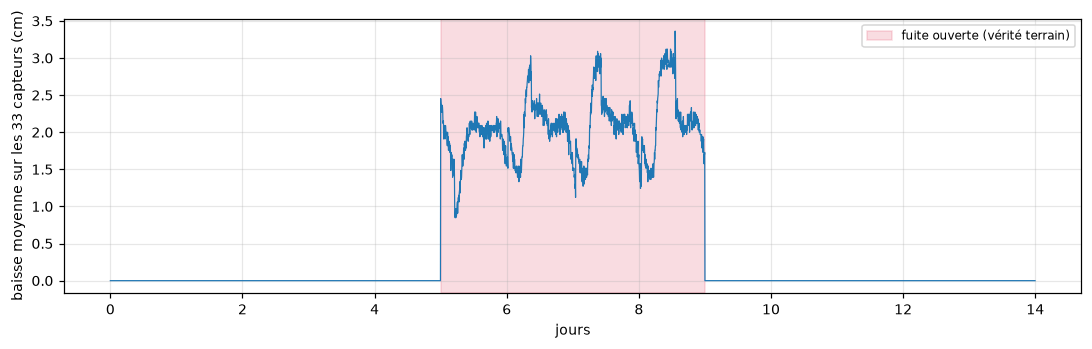

In [13]:
# Ce que ferait un consommateur du lot, sans rien importer de ce dépôt.
idx = pd.read_csv(sortie / "index.csv")
temoin = pd.read_parquet(sortie / "temoin" / "pressions.parquet")
exemple = idx[idx["fuite"]].iloc[6]
serie = pd.read_parquet(sortie / exemple["scenario"] / "pressions.parquet")
verite_ex = json.loads((sortie / exemple["scenario"] / "verite.json").read_text())

print(f"{exemple['scenario']} — {verite_ex['conduite']} au nœud {verite_ex['noeud_perce']}, "
      f"{verite_ex['debit_reel_m3h']:.1f} m³/h réels")
print(f"pressions : {serie.shape[0]} pas × {serie.shape[1]} capteurs, "
      f"du {serie.index[0]} au {serie.index[-1]}")
print(serie.iloc[:3, :5].to_string())

ecart = (temoin - serie).mean(axis=1)
fig, ax = plt.subplots()
ax.plot(np.arange(len(ecart)) / R.PAS_JOUR, 100 * ecart.to_numpy(), lw=0.8)
ax.axvspan(verite_ex["debut"] / R.PAS_JOUR, verite_ex["fin"] / R.PAS_JOUR,
           color="crimson", alpha=0.15, label="fuite ouverte (vérité terrain)")
ax.set_xlabel("jours"); ax.set_ylabel("baisse moyenne sur les 33 capteurs (cm)")
ax.legend(fontsize=8); fig.tight_layout()

### Lecture

La courbe est la signature que le lot met à disposition d'un détecteur, et la bande rouge est la
réponse. On voit ici l'intérêt du témoin : il donne la **différence exacte** entre le réseau avec
et sans fuite, ce qu'aucune mesure réelle ne pourra jamais fournir.

Un détecteur, lui, ne recevra pas cette différence — il n'aura que la série de gauche et devra se
débrouiller. Mais pour l'**évaluer**, disposer du témoin change tout : on peut mesurer exactement
ce qu'il aurait pu voir, et distinguer un détecteur qui manque une fuite détectable d'un détecteur
à qui on demandait l'impossible.

## Ce qu'il faut retenir

1. **Un modèle calibré est un générateur d'étiquettes.** L-Town publie quatorze fuites pour une
   année ; le même réseau simulé en produit autant qu'on veut, avec la conduite, l'heure
   d'ouverture, l'heure de réparation et le volume perdu connus exactement.
2. **Une fuite est un orifice, pas un robinet.** On fixe un coefficient d'émetteur, pas un débit,
   et le débit qui s'établit est plus faible que la consigne — d'autant plus que la fuite est
   grosse. L'étiquette doit porter ce qui a été simulé, jamais ce qui a été demandé.
3. **Ne simuler que ce qui change.** Une fuite ne modifie rien avant son ouverture ni après sa
   réparation : recoller le témoin de part et d'autre divise le coût d'un lot par trois, et le
   recollement est exact au bit près dès lors que les dates tombent sur une frontière de
   réancrage.
4. **La difficulté d'un scénario est un rapport signal sur bruit, pas un débit** — et ce rapport
   dépend d'abord de la **topologie**, ensuite de la distance. Sur L-Town, une fuite de la zone C
   est invisible partout sauf en un point, où elle est deux fois plus grosse que la même fuite en
   zone A+B. Composer un lot en tirant des conduites au hasard donne un lot qui n'enseigne qu'un
   seul des deux régimes, sans qu'on s'en aperçoive.
5. **Mesurer le plancher avant de fabriquer.** Un scénario dont la signature est sous l'erreur du
   modèle est insoluble pour tout le monde ; il a sa place dans un lot, mais il faut savoir qu'il y
   est, sous peine de reprocher à un détecteur de ne pas faire de miracle.
6. **Un lot doit se relire sans le code qui l'a écrit.** Un index, un dossier par scénario, un
   format tabulaire standard et une vérité terrain en clair.
7. **Le témoin est la moitié de la valeur du lot.** Il donne la différence exacte avec et sans
   fuite — ce qu'aucune mesure de terrain ne donnera jamais — et c'est ce qui permet d'évaluer un
   détecteur sur ce qu'il *pouvait* voir.